### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
61               France            127              151            370   
45       Czech Republic            361              170            134   
141  Russian Federation            247              326             73   
99           Luxembourg            236              133            271   
155            Slovakia            196              293            116   
81              Ireland            313              118            165   

     total_litres_of_pure_alcohol  
15                           14.4  
98                           12.9  
3                            12.4  
68                           11.9  
61   

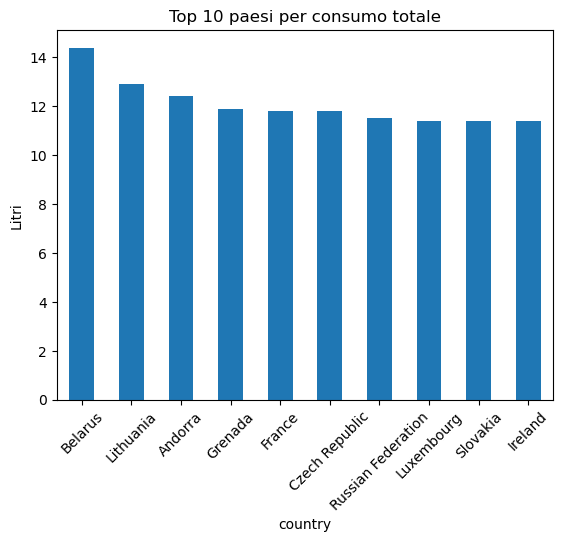

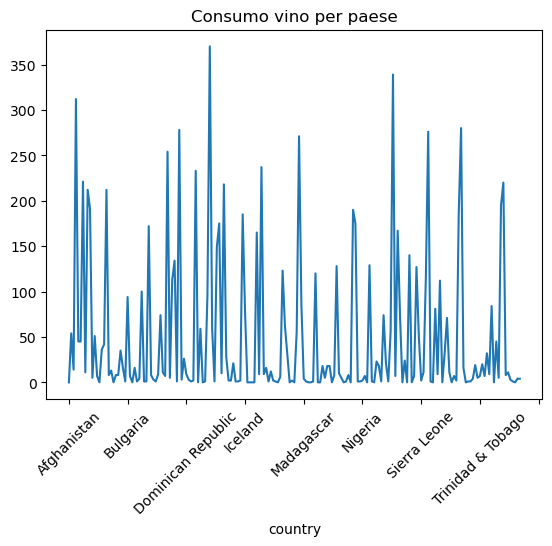

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
print(df.sort_values("total_litres_of_pure_alcohol", ascending=False).head(10))#i 10 piu grandi consumatori
print(df[["beer_servings", "wine_servings", "spirit_servings"]].mean())#la media dei consumi 
df["alcohol_index"] = (df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3#alcohol index
print(df.loc[df["alcohol_index"].idxmax(), "country"]) #valore massimo del alcohol_index
print(df[df["beer_servings"] > 100])#stati con piu di 100 birre annuali
top10 = df.sort_values("total_litres_of_pure_alcohol", ascending=False).head(10)
top10.plot(x="country", y="total_litres_of_pure_alcohol", kind="bar", legend=False)# bar chart
plt.title("Top 10 paesi per consumo totale")
plt.ylabel("Litri")
plt.xticks(rotation=45)#ruota i nomi che non si sovrappongono
plt.show()
df_sorted = df.sort_values("country")#plot di wine_servings
df_sorted.plot(x="country", y="wine_servings", kind="line", legend=False)
plt.title("Consumo vino per paese")
plt.xticks(rotation=45)#ruota i nomi che non si sovrappongono
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

             stipendio_medio  numero_offerte   minimo   massimo
job_country                                                    
Afghanistan              NaN               0      NaN       NaN
Albania         79472.500000               5  43200.0  157500.0
Algeria         44550.000000               2  44100.0   45000.0
Angola                   NaN               0      NaN       NaN
Argentina      105212.343750              32  45000.0  222000.0
...                      ...             ...      ...       ...
Venezuela                NaN               0      NaN       NaN
Vietnam         90927.236364              55  28000.0  200000.0
Yemen                    NaN               0      NaN       NaN
Zambia          90670.000000               1  90670.0   90670.0
Zimbabwe        67056.666667               3  47500.0   90670.0

[160 rows x 4 columns]


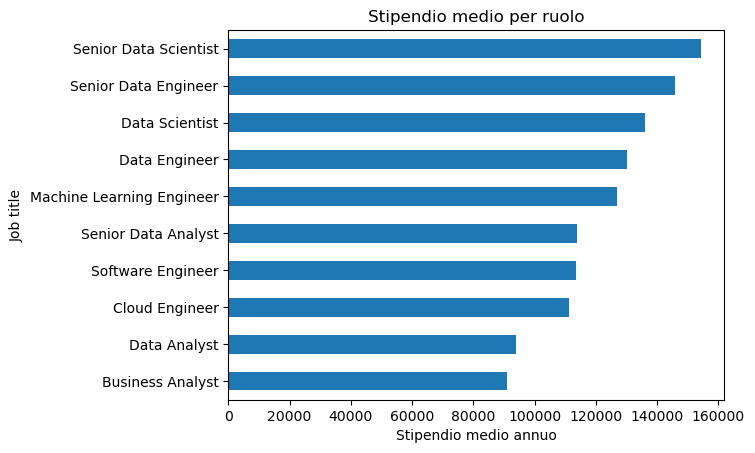

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
print(df.groupby("job_country")["salary_year_avg"].agg(stipendio_medio="mean", numero_offerte="count", minimo="min", massimo="max"))#stipendio medio annuale
df_clean = df.dropna(subset=["salary_year_avg"])#rimuove i NaN
stipendi = df_clean.groupby("job_title_short")["salary_year_avg"].mean()#prende la media
stipendi = stipendi.sort_values(ascending=False)#mette in decrescente
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
stipendi.plot(kind="barh")#grafico a barre orizzontali
plt.title("Stipendio medio per ruolo")
plt.xlabel("Stipendio medio annuo")
plt.ylabel("Job title")
plt.gca().invert_yaxis()#mette i dati in decrescente sul plot
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

           mean  count   min    max
day                                
Fri   17.151579     19  5.75  40.17
Sat   20.441379     87  3.07  50.81
Sun   21.410000     76  7.25  48.17
Thur  17.682742     62  7.51  43.11
   total_bill   tip     sex smoker  day    time  size  conto_per_persona
0       16.99  1.01  Female     No  Sun  Dinner     2           8.495000
1       10.34  1.66    Male     No  Sun  Dinner     3           3.446667
2       21.01  3.50    Male     No  Sun  Dinner     3           7.003333
3       23.68  3.31    Male     No  Sun  Dinner     2          11.840000
4       24.59  3.61  Female     No  Sun  Dinner     4           6.147500
Sun


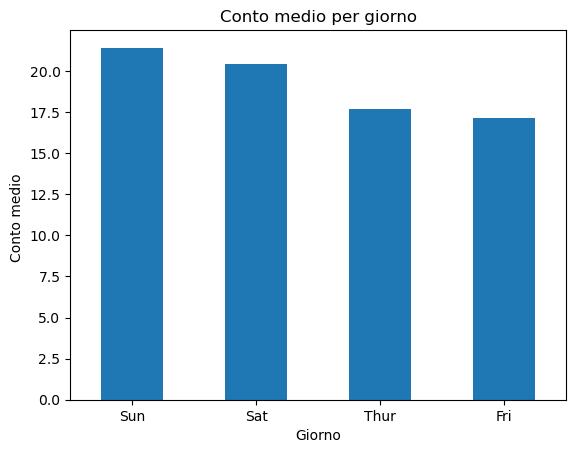

In [16]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
print(df.groupby("day")["total_bill"].agg(mean="mean", count="count", min="min", max="max"))#la media, numero di osservazioni, valori minimi e massimi
df["conto_per_persona"] = df["total_bill"] / df["size"]#aggiunta della colonna
print(df.head())#controllo che la colonna c'e`
print(df.groupby("day")["total_bill"].mean().idxmax())#giorno con conto medio piu alto
media = df.groupby("day")["total_bill"].mean().sort_values(ascending=False)#conto medio rappresentato
media.plot(kind="bar")
plt.title("Conto medio per giorno")          
plt.xlabel("Giorno")                         
plt.ylabel("Conto medio ")                
plt.xticks(rotation=0) 
plt.xticks(rotation=0)
plt.show()